In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!rm -rf /content/mbt_gym /content/mbt_repo

# Clone your branch
!git clone -b MMwithFadsInfUnifTraders_full_info https://github.com/andreacate/mbt_gym.git

# Rename folder to avoid namespace package conflicts
!mv /content/mbt_gym /content/mbt_repo


Cloning into 'mbt_gym'...
remote: Enumerating objects: 4097, done.
remote: Counting objects: 100% (582/582), done.
remote: Compressing objects: 100% (346/346), done.
remote: Total 4097 (delta 260), reused 335 (delta 224), pack-reused 3515 (from 3)
Receiving objects: 100% (4097/4097), 518.26 MiB | 3.23 MiB/s, done.
Resolving deltas: 100% (1954/1954), done.
Updating files: 100% (718/718), done.


In [ ]:
import sys

# Remove any previous broken entries
sys.path = [p for p in sys.path if "mbt_gym" not in p and "mbt_repo" not in p]

# Add ONLY the correct parent folder
sys.path.append("/content/mbt_repo")

# Check that Python now finds the package
import importlib.util
print(importlib.util.find_spec("mbt_gym"))

ModuleSpec(name='mbt_gym', loader=<_frozen_importlib_external.SourceFileLoader object at 0x77fdd82b4b90>, origin='/content/mbt_repo/mbt_gym/__init__.py', submodule_search_locations=['/content/mbt_repo/mbt_gym'])


In [4]:
!pip install stable-baselines3[extra]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 6.6 MB/s eta 0:00:00


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import seaborn as sns
from scipy.integrate import quad
import torch
from torch import nn
from datetime import datetime
from matplotlib.gridspec import GridSpec
from tensorboard.backend.event_processing import event_accumulator

from copy import deepcopy

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback, CallbackList
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecMonitor
from stable_baselines3.common.monitor import Monitor

In [3]:
import sys
sys.path.append("../../")

In [4]:
from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics
from mbt_gym.agents.SbAgent import SbAgent
from mbt_gym.agents.BaselineAgents import *
from mbt_gym.stochastic_processes.midprice_models import *
from mbt_gym.stochastic_processes.arrival_models import *
from mbt_gym.stochastic_processes.fill_probability_models import *

# helpers
from mbt_gym.gym.TradingEnvironment import TradingEnvironment
from mbt_gym.gym.StableBaselinesTradingEnvironment import StableBaselinesTradingEnvironment
from mbt_gym.gym.index_names import *
from mbt_gym.gym.helpers.plotting import *
from mbt_gym.gym.helpers.generate_trajectory import generate_trajectory
from mbt_gym.gym.wrappers import *

In [5]:
seed_value = 42
global seed
seed = seed_value

# Reset seeds for all randomness sources
np.random.seed(seed)
torch.manual_seed(seed)

import random
random.seed(seed)

base_seed = 42
seed_train = base_seed
seed_visualization = base_seed + 1
seed_evaluation = base_seed + 2
test_evaluation = base_seed + 3

In [6]:
max_inventory = 20

In [7]:
initial_price = 100
terminal_time = 1.0
sigma = 1.0
n_steps = 75
initial_inventory = 0
fads_proportion = 0.6 # p is defined directly inside the ArithmeticBrownianMotionWithFadsMidpriceModel class as sqrt(1-q^2)
eta = 10
phi = 15
k = 1
fill_exponent = k
gamma = k
alpha=0.001
mu=0
big_phi=0.1

In [8]:
# OU parameters
u0 = 0.0
xi = 1.0

def m(t):
    return u0 * np.exp(-eta * t)

def v(t):
    return (xi**2) / (2.0 * eta) * (1.0 - np.exp(-2.0 * eta * t))

def compute_psi(q):
    c = gamma * sigma * q
    def integrand(t):
        return np.exp(c * m(t) + 0.5 * (c**2) * v(t))
    denom, _ = quad(integrand, 0.0, terminal_time)
    return (30.0 - phi * terminal_time) / denom

# compute psi for each fad proportion
psi = compute_psi(fads_proportion)

print("psi value:", psi)

psi value: 14.872283180889763


In [9]:
def get_closed_form_env(num_trajectories:int = 1, fads_proportion:float=0.6,
               psi:float = 15.0, phi:float = 15.0, eta:float = 10.0,
               gamma:float = 1.0,
               ) -> TradingEnvironment:
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k,
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model,
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time,
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=max_inventory,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [10]:
pi_env = get_closed_form_env(fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)

In [11]:
pi_agent = OptimizedFullInfoMMwithFadsInformedUniformedTradersAgent(env=pi_env)
print(pi_env.model_dynamics
      .midprice_model)


✓ Pre-computed ODE solutions for 75 time points


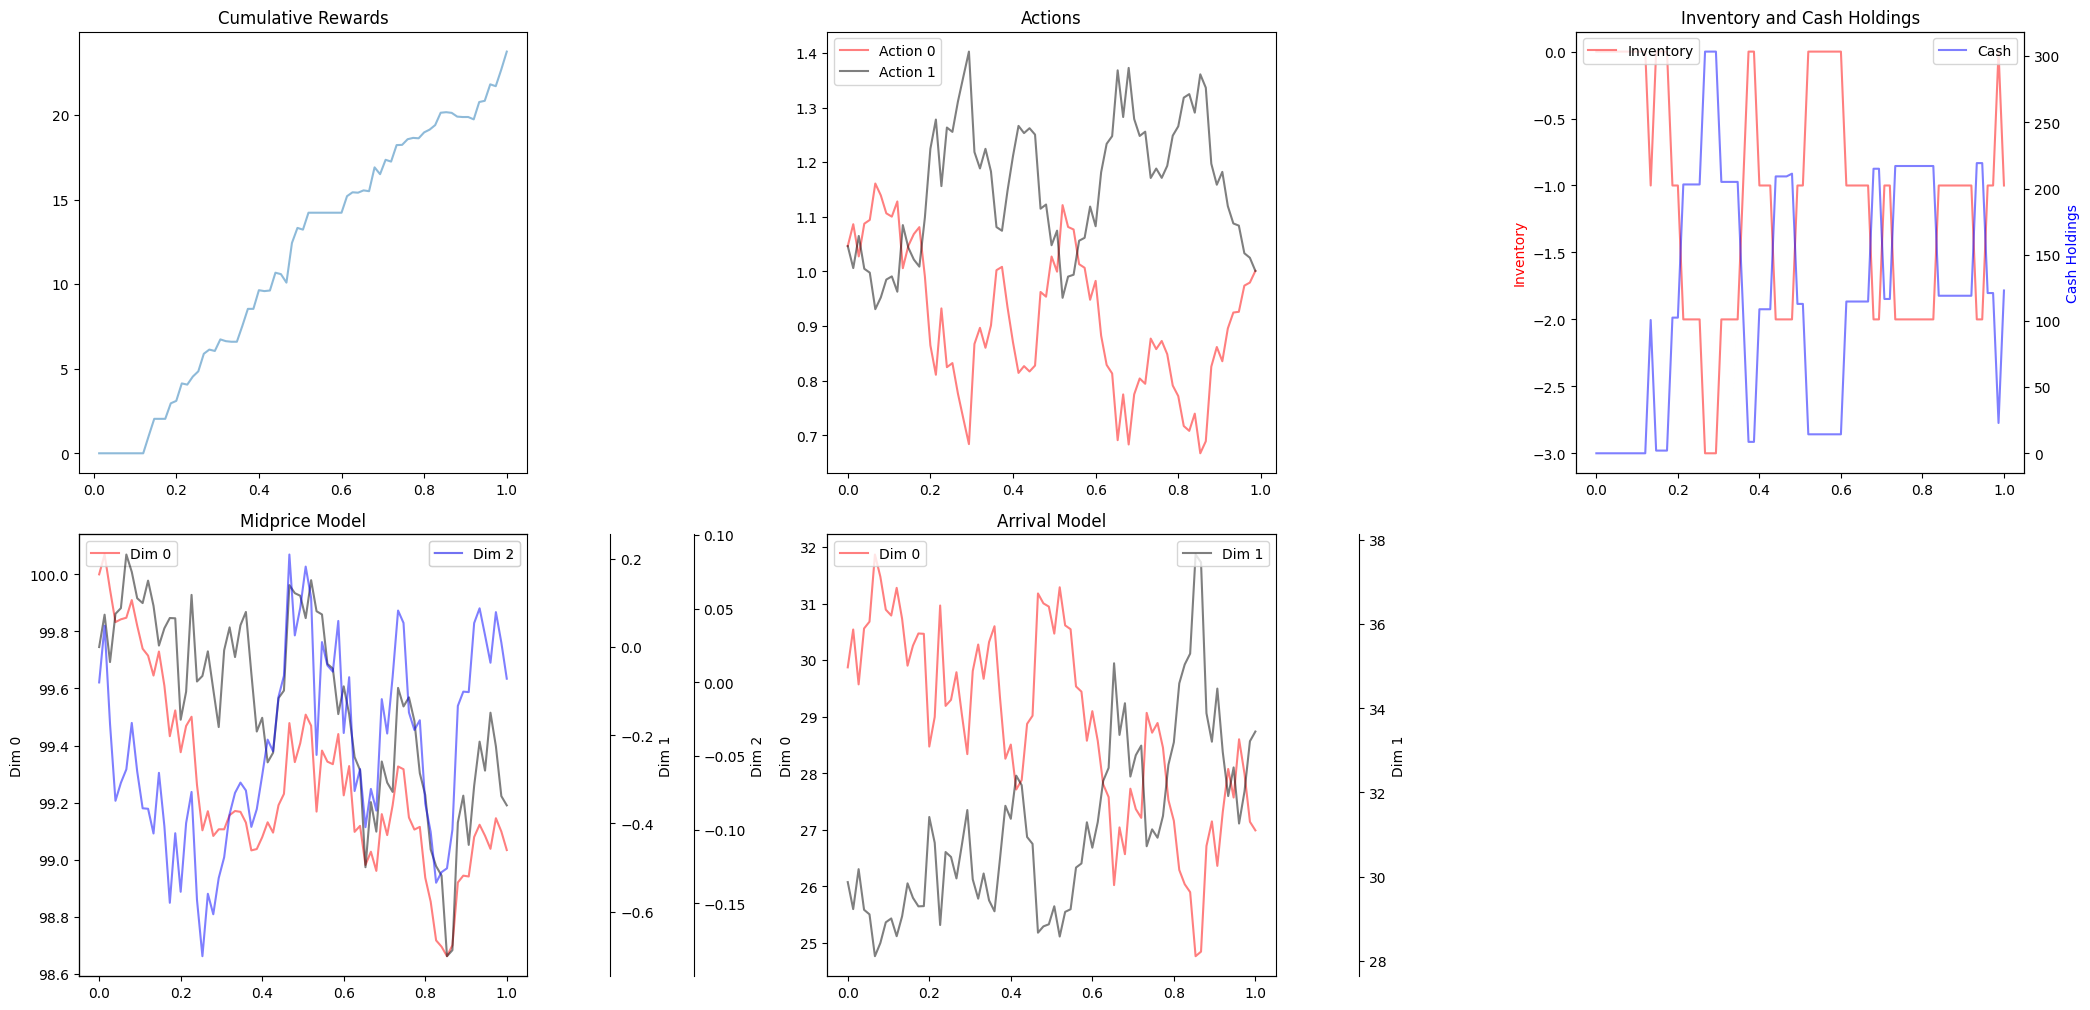

In [12]:
plot_trajectory_extended(pi_env, pi_agent)

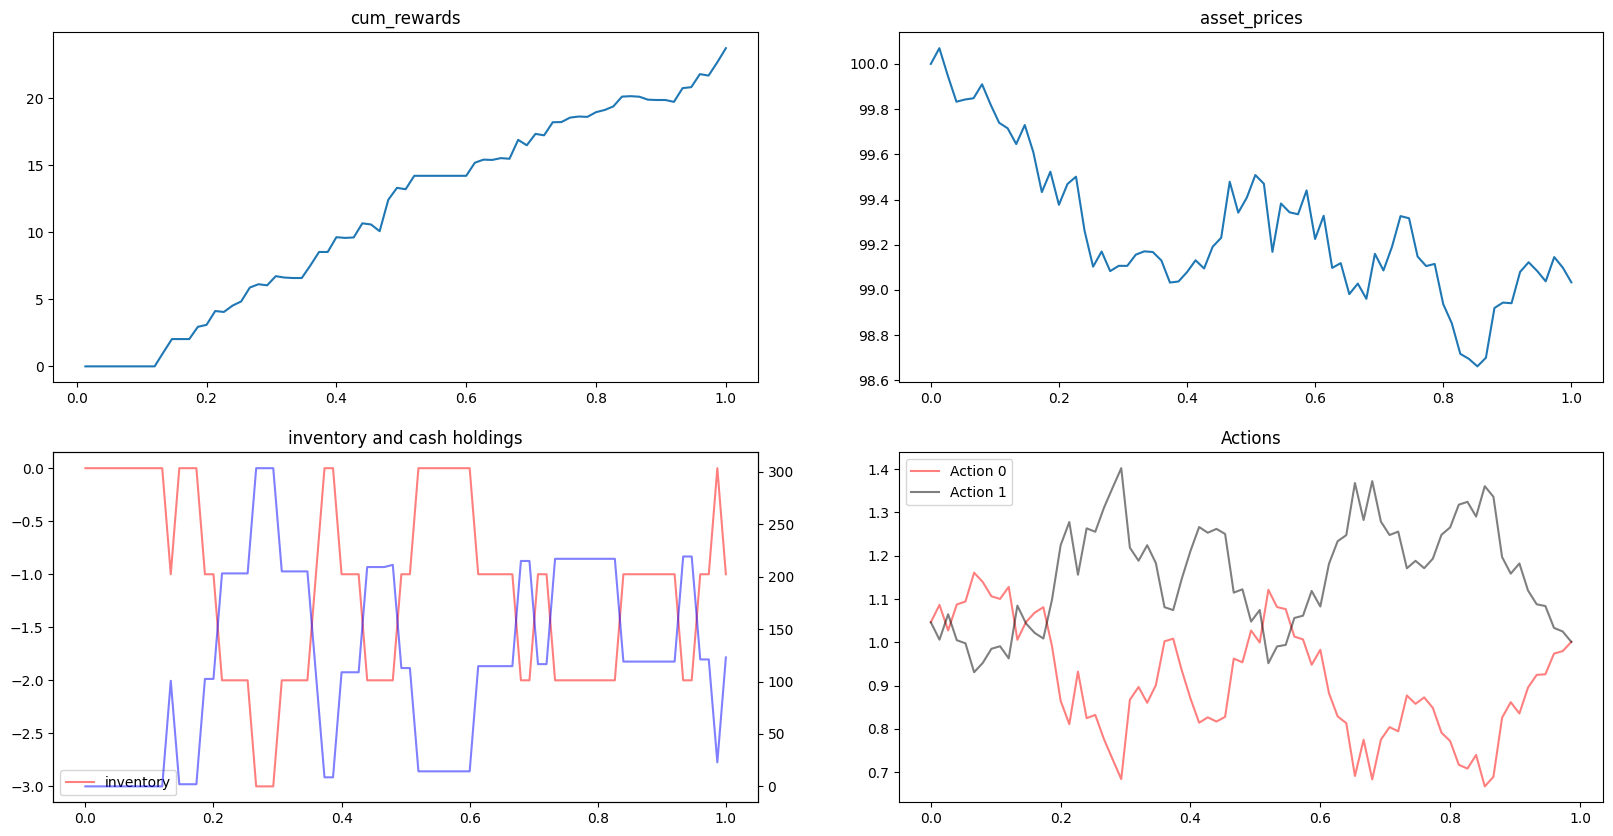

In [13]:
plot_trajectory(pi_env, pi_agent, seed = seed)

In [14]:
num_trajectories = 1000
vec_env_pi = get_closed_form_env(num_trajectories, fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)
vec_agent_pi = OptimizedFullInfoMMwithFadsInformedUniformedTradersAgent(env=vec_env_pi)

✓ Pre-computed ODE solutions for 75 time points


In [15]:
observations_pi, actions_pi, rewards_pi = generate_trajectory(vec_env_pi, vec_agent_pi)

In [16]:
results_pi, fig_pi, total_rewards_pi = generate_results_table_and_hist(vec_env=vec_env_pi,agent=vec_agent_pi)

In [17]:
results_pi

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
Inventory,2.065165,21.354331,4.435084,0.161,2.926957


### Rinforncement Learning

In [18]:
def compute_distance_score(inventories, rl_bid, rl_ask, pi_bid, pi_ask):
    """
    Compute the Distance Score as the sum of absolute differences
    between RL and PI spreads across all inventory levels.
    """
    bid_distance = np.sum(np.abs(np.array(rl_bid) - np.array(pi_bid)))
    ask_distance = np.sum(np.abs(np.array(rl_ask) - np.array(pi_ask)))
    total_distance = bid_distance + ask_distance

    return {
        'total_distance': total_distance,
        'bid_distance': bid_distance,
        'ask_distance': ask_distance
    }

In [19]:
def get_rl_env(num_trajectories:int = 1, fads_proportion:float=0.6,
               psi:float = 15.0, phi:float = 15.0, eta:float = 10.0,
               gamma:float = 1.0, n_steps:int = n_steps
               ) -> TradingEnvironment:
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k,
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model,
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time,
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      #initial_inventory = random_initial_inventory,
                      #start_time = make_random_start_time_sampler(terminal_time),
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=max_inventory,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      normalise_rewards = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [20]:
def get_rl_env_visualization(num_trajectories:int = 1, fads_proportion:float=0.6,
               psi:float = 15.0, phi:float = 15.0, eta:float = 10.0,
               gamma:float = 1.0, n_steps:int = n_steps
               ) -> TradingEnvironment:
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k,
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model,
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time,
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      #initial_inventory = random_initial_inventory,
                      #start_time = make_random_start_time_sampler(terminal_time),
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory = max_inventory,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      normalise_rewards = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [21]:
total_steps = 2_000
#eval_freq = total_steps // 10
n_eval_episodes = 256

In [22]:
from stable_baselines3.common.callbacks import BaseCallback

class EntropyDecayCallback(BaseCallback):
    def __init__(self, initial_ent_coef=0.05, final_ent_coef=0.001, decay_steps=10_000_000, verbose=0):
        super().__init__(verbose)
        self.initial_ent_coef = initial_ent_coef
        self.final_ent_coef = final_ent_coef
        self.decay_steps = decay_steps

    def _on_step(self) -> bool:
        progress = min(1.0, self.num_timesteps / self.decay_steps)
        new_ent_coef = self.initial_ent_coef * (1 - progress) + self.final_ent_coef * progress
        self.model.ent_coef = new_ent_coef
        return True

In [23]:
use_normalized_agent = False


Testing n_steps = 10

Using cpu device


/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/gymnasium/spaces/box.py:225: RuntimeWarning: overflow encountered in cast
  elif low.dtype != self.dtype and np.any(low < dtype_min):
/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/gymnasium/spaces/box.py:295: RuntimeWarning: overflow encountered in cast
  elif high.dtype != self.dtype and np.any(dtype_max < high):


Logging to .././Partial_Info_models/tensorboard/PPO-learning/PIMm_PPO_systematic_n_steps_10/2025-12-05_18-06-33/PPO_1


Output()

-------------------------------
| time/              |        |
|    fps             | 280413 |
|    iterations      | 1      |
|    time_elapsed    | 0      |
|    total_timesteps | 75000  |
-------------------------------


...

RL Results:           Mean spread  Mean PnL   Std PnL  PnL CI 95% low  PnL CI 95% high  \
RL Agent     0.081817 -1.192347  5.823625        -1.55373        -0.830964   

          Mean terminal inventory  Std terminal inventory  
RL Agent                   -1.338                7.354166  
PI-Distance Score: 13.9481

Testing n_steps = 1000

Using cpu device
Logging to .././Partial_Info_models/tensorboard/PPO-learning/PIMm_PPO_systematic_n_steps_1000/2025-12-05_18-07-00/PPO_1


Output()

/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/gymnasium/spaces/box.py:225: RuntimeWarning: overflow encountered in cast
  elif low.dtype != self.dtype and np.any(low < dtype_min):
/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/gymnasium/spaces/box.py:295: RuntimeWarning: overflow encountered in cast
  elif high.dtype != self.dtype and np.any(dtype_max < high):


-------------------------------
| time/              |        |
|    fps             | 330625 |
|    iterations      | 1      |
|    time_elapsed    | 0      |
|    total_timesteps | 75000  |
-------------------------------


RL Results:           Mean spread  Mean PnL   Std PnL  PnL CI 95% low  PnL CI 95% high  \
RL Agent        0.027 -2.677319  6.117415       -3.056933        -2.297704   

          Mean terminal inventory  Std terminal inventory  
RL Agent                   -1.014                7.737429  
PI-Distance Score: 14.3272

FINAL RESULTS
   n_steps  total_distance  bid_distance  ask_distance  mean_pnl_rl  \
0       10       13.180223      6.740080      6.440143     1.592955   
1       20       13.329493      6.597492      6.732000     2.952454   
2       50       13.541402      6.821648      6.719754     2.338243   
3      100       13.485570      6.664006      6.821564     1.569210   
4      200       13.737927      6.878768      6.859159     0.300540   
5      500       13.948122      6.829545      7.118577    -1.192347   
6     1000       14.327227      7.067472      7.259755    -2.677319   

   mean_pnl_pi  
0    21.354331  
1    21.354331  
2    21.354331  
3    21.354331  
4    21.354331 

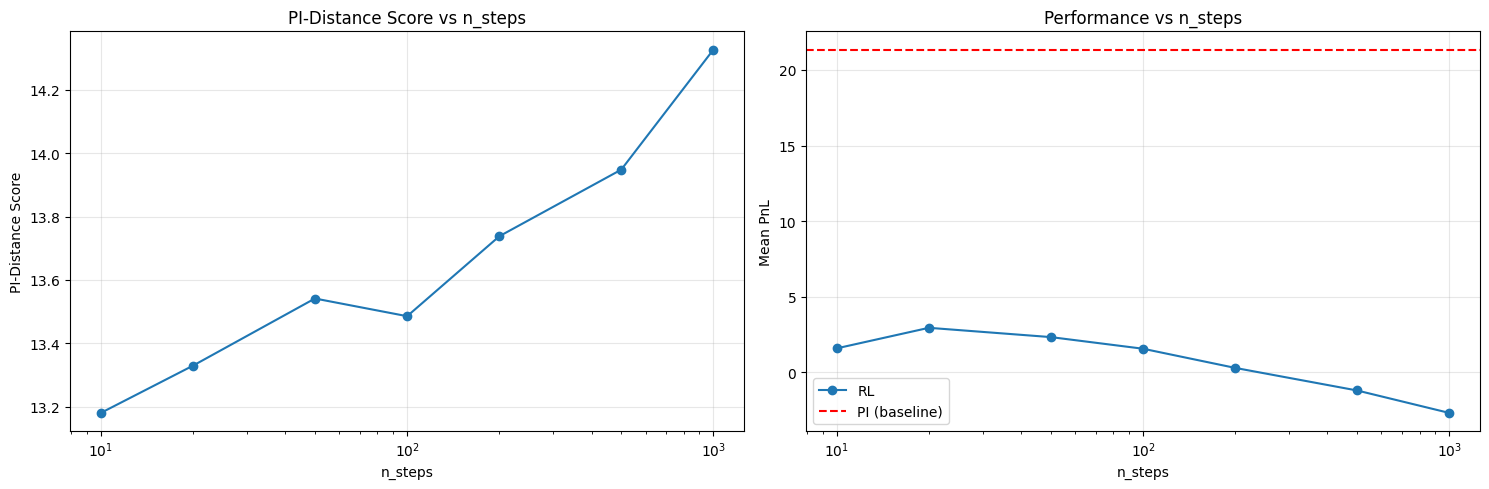

In [24]:
# Define the range of n_steps to test
n_steps_candidates = [10, 20, 50, 100, 200, 500, 1000]

results_summary = []

for n_steps_test in n_steps_candidates:
    print(f"\n{'='*60}")
    print(f"Testing n_steps = {n_steps_test}")
    print(f"{'='*60}\n")


    # 2. Recompute psi with new n_steps (if needed)
    psi = compute_psi(fads_proportion)

    # 3. Create new environment and train PPO
    num_trajectories = 1000
    reduced_training_indices = [INVENTORY_INDEX, TIME_INDEX, ASSET_PRICE_INDEX, FILTERED_FADS_INDEX]
    rl_env = ReduceStateSizeWrapper(get_rl_env(num_trajectories, n_steps=n_steps_test), reduced_training_indices)
    sb_rl_env = StableBaselinesTradingEnvironment(trading_env=rl_env)

    # Generate timestamp string
    run_id = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    experiment_name = f"PIMm_PPO_systematic_n_steps_{n_steps_test}"
    # Paths with timestamp
    tensorboard_logdir = f".././Partial_Info_models/tensorboard/PPO-learning/{experiment_name}/{run_id}/"
    best_model_path = f".././Partial_Info_models/PPO-best/{experiment_name}/{run_id}/"


    policy_kwargs = dict(
        activation_fn=nn.Tanh,
        net_arch=dict(pi=[256, 256], vf=[256, 256])
    )

    n_epochs = 10
    learning_rate = 3e-4
    gae_lambda = 0.95
    clip_range = 0.2
    vf_coef = 0.5
    max_grad_norm = 0.5

    PPO_params = {"policy":'MlpPolicy', "env": sb_rl_env, "verbose":1,
                "policy_kwargs":policy_kwargs,
                "tensorboard_log":tensorboard_logdir,
                "n_epochs":n_epochs,
                "batch_size": int(n_steps * num_trajectories / 10),
                "n_steps": int(n_steps),
                "learning_rate": learning_rate,
                "gae_lambda": gae_lambda,
                "clip_range": clip_range,
                "vf_coef": vf_coef,
                "max_grad_norm": max_grad_norm,
                #"ent_coef": 0.05 # added ent_coef to encourage exploration
                    }

    callback_params = dict(eval_env=sb_rl_env, n_eval_episodes=n_eval_episodes,
                        #eval_freq=eval_freq,
                        best_model_save_path = best_model_path,
                        deterministic=True)

    entropy_decay_callback = EntropyDecayCallback(initial_ent_coef=0.05, final_ent_coef=0.001, decay_steps=10_000_000)
    callback = CallbackList([EvalCallback(**callback_params), entropy_decay_callback])

    #callback = EvalCallback(**callback_params)
    model = PPO(**PPO_params, device="cuda")

    model.learn(total_timesteps = total_steps, callback=callback, progress_bar=True)

    # 4. Evaluate the trained model
    rl_env_evaluation = get_rl_env_visualization(num_trajectories=1000, n_steps=n_steps_test)

    ppo_agent = SbAgent(model, reduced_training_indices=reduced_training_indices, env=rl_env_evaluation, use_normalized_agent=use_normalized_agent)

    results_rl, fig, tot_rewards = generate_results_table_and_hist_rl_fast(vec_env=rl_env_evaluation, rl_agent=ppo_agent)

    print("RL Results:", results_rl)

    # Get RL actions
    inventories = np.arange(-3, 4, 1)
    rl_bid_actions = []
    rl_ask_actions = []
    for inv in inventories:
        bid, ask = ppo_agent.get_action(np.array([[inv, 0.5, 100, 0]])).reshape(-1)
        rl_bid_actions.append(bid)
        rl_ask_actions.append(ask)

    # Get PI actions
    pi_bid_actions = []
    pi_ask_actions = []
    for inv in inventories:
        bid, ask = pi_agent.get_action(np.array([[0,inv,0.5,100,0]])).reshape(-1)
        pi_bid_actions.append(bid)
        pi_ask_actions.append(ask)

    # 5. Compute PI-Distance Score
    scores = compute_distance_score(inventories, rl_bid_actions, rl_ask_actions,
                                       pi_bid_actions, pi_ask_actions)

    # 6. Store results
    results_summary.append({
        'n_steps': n_steps_test,
        'total_distance': scores['total_distance'],
        'bid_distance': scores['bid_distance'],
        'ask_distance': scores['ask_distance'],
        'mean_pnl_rl': results_rl["Mean PnL"].iloc[0],
        'mean_pnl_pi': results_pi["Mean PnL"].iloc[0]
    })

    print(f"PI-Distance Score: {scores['total_distance']:.4f}")

# Convert to DataFrame for easy analysis
results_df = pd.DataFrame(results_summary)
print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)
print(results_df)

# Plot the results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distance vs n_steps
axes[0].plot(results_df['n_steps'], results_df['total_distance'], 'o-')
axes[0].set_xlabel('n_steps')
axes[0].set_ylabel('PI-Distance Score')
axes[0].set_title('PI-Distance Score vs n_steps')
axes[0].grid(alpha=0.3)
axes[0].set_xscale('log')

# PnL comparison
axes[1].plot(results_df['n_steps'], results_df['mean_pnl_rl'], 'o-', label='RL')
axes[1].axhline(y=results_df['mean_pnl_pi'].iloc[0], linestyle='--',
                color='r', label='PI (baseline)')
axes[1].set_xlabel('n_steps')
axes[1].set_ylabel('Mean PnL')
axes[1].set_title('Performance vs n_steps')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

In [25]:
results_df.to_csv("/content/drive/MyDrive/Thesis/Partial_Info_models/results_summary.csv", index=False)

OSError: Cannot save file into a non-existent directory: '/content/drive/MyDrive/Thesis/Partial_Info_models'

In [ ]:
!ls -lh /content/drive/MyDrive/Thesis/Partial_Info_models/

total 199K
drwx------ 2 root root 4.0K Dec  2 14:17 PPO-best
-rw------- 1 root root 190K Dec  5 15:38 results_plot.png
-rw------- 1 root root  755 Dec  5 16:17 results_summary.csv
drwx------ 2 root root 4.0K Dec  2 14:17 tensorboard


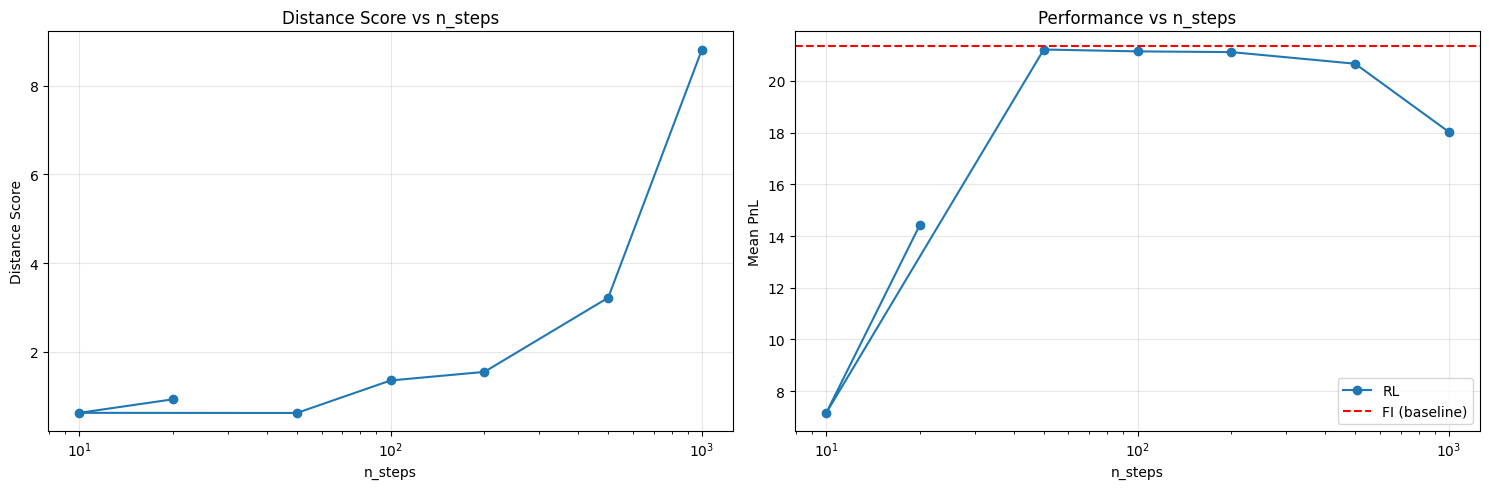

In [ ]:
# Plot the results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distance vs n_steps
axes[0].plot(results_df['n_steps'], results_df['total_distance'], 'o-')
axes[0].set_xlabel('n_steps')
axes[0].set_ylabel('Distance Score')
axes[0].set_title('Distance Score vs n_steps')
axes[0].grid(alpha=0.3)
axes[0].set_xscale('log')

# PnL comparison
axes[1].plot(results_df['n_steps'], results_df['mean_pnl_rl'], 'o-', label='RL')
axes[1].axhline(y=results_df['mean_pnl_pi'].iloc[0], linestyle='--',
                color='r', label='PI (baseline)')
axes[1].set_xlabel('n_steps')
axes[1].set_ylabel('Mean PnL')
axes[1].set_title('Performance vs n_steps')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xscale('log')

plt.tight_layout()
# SAVE THE FIGURE
plt.savefig("/content/drive/MyDrive/Thesis/Partial_Info_models/results_plot.png", dpi=300, bbox_inches="tight")
plt.show()